# Assignment 2 
**CS6103** 

This notebook implements Multinomial Naive Bayes and Multivariate Bernoulli Naive Bayes from scratch on the UCI Cleveland Heart Disease data.

In [1]:
import csv
import math
import copy
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

DATA_PATH = "data/processed.cleveland.data"

COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]
CONTINUOUS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
FEATURES = CATEGORICAL + CONTINUOUS
TARGET = "num"

## 1. Data loading and cleaning

In [2]:
def load_cleveland(path):
    rows = []
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        for raw in reader:
            if not raw:
                continue
            row = {}
            for j, col in enumerate(COLUMNS):
                value = raw[j].strip()
                row[col] = None if value == "?" else float(value)
            row[TARGET] = int(row[TARGET])
            rows.append(row)
    return rows

data = load_cleveland(DATA_PATH)
print("Records:", len(data))
print("Attributes including target:", len(COLUMNS))

class_counts = {}
for row in data:
    class_counts[row[TARGET]] = class_counts.get(row[TARGET], 0) + 1
print("Class distribution:", dict(sorted(class_counts.items())))

Records: 303
Attributes including target: 14
Class distribution: {0: 164, 1: 55, 2: 36, 3: 35, 4: 13}


In [3]:
def missing_count(rows):
    return {
        feature: sum(row[feature] is None for row in rows)
        for feature in FEATURES
    }

print("Missing values by feature:")
print(missing_count(data))

# Retaining missing values for experiments

Missing values by feature:
{'sex': 0, 'cp': 0, 'fbs': 0, 'restecg': 0, 'exang': 0, 'slope': 0, 'ca': 4, 'thal': 2, 'age': 0, 'trestbps': 0, 'chol': 0, 'thalach': 0, 'oldpeak': 0}


## 2. Stratified 5-fold cross-validation

In [4]:
def make_stratified_folds(rows, n_folds=5, seed=SEED):
    local_rng = np.random.default_rng(seed)
    by_class = {}
    for i, row in enumerate(rows):
        by_class.setdefault(row[TARGET], []).append(i)

    folds = [[] for _ in range(n_folds)]
    for c in sorted(by_class):
        indices = np.array(by_class[c], dtype=int)
        local_rng.shuffle(indices)
        for j, idx in enumerate(indices):
            folds[j % n_folds].append(int(idx))

    return [np.array(sorted(fold), dtype=int) for fold in folds]


folds = make_stratified_folds(data)

for i, fold in enumerate(folds, 1):
    counts = {}
    for idx in fold:
        c = data[idx][TARGET]
        counts[c] = counts.get(c, 0) + 1
    print(f"Fold {i}: {len(fold)} records | {dict(sorted(counts.items()))}")

Fold 1: 62 records | {0: 33, 1: 11, 2: 8, 3: 7, 4: 3}
Fold 2: 61 records | {0: 33, 1: 11, 2: 7, 3: 7, 4: 3}
Fold 3: 61 records | {0: 33, 1: 11, 2: 7, 3: 7, 4: 3}
Fold 4: 60 records | {0: 33, 1: 11, 2: 7, 3: 7, 4: 2}
Fold 5: 59 records | {0: 32, 1: 11, 2: 7, 3: 7, 4: 2}


## 3. Training-only binning and token representation

### Text-preprocessing
Tokenization, lowercasing, and stopword removal are not applied to the original attributes because the dataset is structured tabular data.

In [5]:
def fit_binner(train_rows, n_bins=10, mode="equal-width"):
    thresholds = {}
    for feature in CONTINUOUS:
        values = np.array([row[feature] for row in train_rows if row[feature] is not None], dtype=float)

        if mode == "equal-width":
            lo, hi = values.min(), values.max()
            edges = np.linspace(lo, hi, n_bins + 1)

        elif mode == "quantile":
            edges = np.unique(np.quantile(values, np.linspace(0, 1, n_bins + 1)))

        else:
            raise ValueError("mode must be 'equal-width' or 'quantile'")
            
        thresholds[feature] = edges
    return thresholds

def apply_binner(rows, thresholds):
    transformed = []
    for row in rows:
        new = dict(row)
        for feature in CONTINUOUS:
            value = row[feature]
            if value is None:
                new[feature] = "missing"
            else:
                edges = thresholds[feature]
                # Bin labels are 0, 1, ..., number_of_actual_bins-1.
                new[feature] = int(np.searchsorted(edges[1:-1], value, side="right"))
        transformed.append(new)
    return transformed

def rows_to_tokens(rows, add_shuffled=False, shuffled_values=None):
    token_rows = []
    for i, row in enumerate(rows):
        tokens = []
        for feature in FEATURES:
            value = row[feature]
            value_text = "missing" if value is None else str(value)
            tokens.append(f"{feature}={value_text}")
        if add_shuffled:
            tokens.append(f"shuffled_token={shuffled_values[i]}")
        token_rows.append(tokens)
    return token_rows

def prepare_fold(data_rows, train_idx, test_idx, n_bins=10, mode="equal-width",
                 remove_incomplete=False):
    if remove_incomplete:
        # This mode is handled before fold creation in the experiment below.
        raise ValueError("Use make_clean_dataset() before creating folds.")

    train_rows = [data_rows[i] for i in train_idx]
    test_rows = [data_rows[i] for i in test_idx]

    thresholds = fit_binner(train_rows, n_bins=n_bins, mode=mode)
    train_binned = apply_binner(train_rows, thresholds)
    test_binned = apply_binner(test_rows, thresholds)

    X_train = rows_to_tokens(train_binned)
    X_test = rows_to_tokens(test_binned)
    y_train = np.array([r[TARGET] for r in train_rows], dtype=int)
    y_test = np.array([r[TARGET] for r in test_rows], dtype=int)

    return X_train, X_test, y_train, y_test, thresholds

## 4. Multinomial Naive Bayes

In [6]:
class MultinomialNB:
    def __init__(self, alpha=1.0, prior_type="empirical"):
        self.alpha = alpha
        self.prior_type = prior_type
        self.classes = None
        self.priors = {}
        self.vocabulary = set()
        self.token_counts = {}
        self.log_likelihoods = {}

    def fit(self, X_tokens, y):
        self.classes = np.array(sorted(set(y)))
        self.vocabulary = {t for tokens in X_tokens for t in tokens}

        # Priors
        for c in self.classes:
            count = np.sum(y == c)
            self.priors[c] = (count / len(y) if self.prior_type == "empirical" else 1 / len(self.classes))

        # Count tokens
        self.token_counts = {
            c: {t: 0 for t in self.vocabulary}
            for c in self.classes
        }

        for tokens, c in zip(X_tokens, y):
            for token in tokens:
                self.token_counts[c][token] += 1

        # Log probabilities
        V = len(self.vocabulary)

        for c in self.classes:
            total = sum(self.token_counts[c].values())
            denominator = total + self.alpha * V

            self.log_likelihoods[c] = {
                token: math.log((self.token_counts[c][token] + self.alpha) / denominator)
                for token in self.vocabulary
            }

        return self

    def _score_tokens(self, tokens):
        scores = {}

        for c in self.classes:
            score = math.log(self.priors[c])
            total = sum(self.token_counts[c].values())

            for token in tokens:
                if token in self.vocabulary:
                    score += self.log_likelihoods[c][token]
                else:
                    denominator = total + self.alpha * (len(self.vocabulary) + 1)
                    score += math.log(self.alpha / denominator)

            scores[c] = score

        return scores

    def predict_log_proba(self, X_tokens):
        return np.array([[self._score_tokens(tokens)[c] for c in self.classes] for tokens in X_tokens])

    def predict_proba(self, X_tokens):
        log_scores = self.predict_log_proba(X_tokens)
        scores = np.exp(log_scores - np.max(log_scores, axis=1, keepdims=True))
        return scores / scores.sum(axis=1, keepdims=True)

    def predict(self, X_tokens):
        return self.classes[np.argmax(self.predict_proba(X_tokens), axis=1)]


## 5. Multivariate Bernoulli Naive Bayes

In [7]:
class BernoulliNB:
    def __init__(self, alpha=1.0, prior_type="empirical"):
        self.alpha = alpha
        self.prior_type = prior_type
        self.classes = None
        self.priors = {}
        self.vocabulary = set()
        self.log_present = {}
        self.log_absent = {}

    def fit(self, X_tokens, y):
        self.classes = np.array(sorted(set(y)))
        self.vocabulary = {t for tokens in X_tokens for t in tokens}

        # Priors
        for c in self.classes:
            count = np.sum(y == c)
            self.priors[c] = (
                count / len(y)
                if self.prior_type == "empirical" else 1 / len(self.classes)
            )

        # Present/absent probabilities
        for c in self.classes:
            self.log_present[c] = {}
            self.log_absent[c] = {}

            n_c = np.sum(y == c)

            for token in self.vocabulary:
                count = sum(
                    token in set(tokens) for tokens, label in zip(X_tokens, y) 
                    if label == c
                )

                denominator = n_c + 2 * self.alpha

                self.log_present[c][token] = math.log((count + self.alpha) / denominator)
                self.log_absent[c][token] = math.log((n_c - count + self.alpha) / denominator)

        return self

    def _score_tokens(self, tokens):
        present = set(tokens)
        scores = {}

        for c in self.classes:
            scores[c] = math.log(self.priors[c])

            for token in self.vocabulary:
                if token in present:
                    scores[c] += self.log_present[c][token]
                else:
                    scores[c] += self.log_absent[c][token]

        return scores

    def predict_log_proba(self, X_tokens):
        return np.array([
            [self._score_tokens(tokens)[c] for c in self.classes]
            for tokens in X_tokens
        ])

    def predict_proba(self, X_tokens):
        log_scores = self.predict_log_proba(X_tokens)
        scores = np.exp(log_scores - np.max(log_scores, axis=1, keepdims=True))
        return scores / scores.sum(axis=1, keepdims=True)

    def predict(self, X_tokens):
        return self.classes[np.argmax(self.predict_proba(X_tokens), axis=1)]

## 6. Evaluation metrics

In [8]:
def confusion_matrix_manual(y_true, y_pred, classes):
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    index = {c: i for i, c in enumerate(classes)}
    for yt, yp in zip(y_true, y_pred):
        cm[index[yt], index[yp]] += 1
    return cm

def precision_recall_f1(y_true, y_pred, classes):
    cm = confusion_matrix_manual(y_true, y_pred, classes)
    precision, recall, f1 = [], [], []

    for i in range(len(classes)):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        p = tp / (tp + fp) if tp + fp else 0.0
        r = tp / (tp + fn) if tp + fn else 0.0
        f = 2*p*r/(p+r) if p+r else 0.0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    return np.array(precision), np.array(recall), np.array(f1), cm

def accuracy_score_manual(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def micro_f1(y_true, y_pred, classes):
    cm = confusion_matrix_manual(y_true, y_pred, classes)
    tp = np.trace(cm)
    fp = np.sum(cm) - tp
    fn = fp
    return 2*tp/(2*tp + fp + fn) if (2*tp + fp + fn) else 0.0

def evaluate(y_true, y_pred, classes):
    p, r, f, cm = precision_recall_f1(y_true, y_pred, classes)
    return {
        "accuracy": accuracy_score_manual(y_true, y_pred),
        "precision_macro": np.mean(p),
        "recall_macro": np.mean(r),
        "f1_macro": np.mean(f),
        "f1_micro": micro_f1(y_true, y_pred, classes),
        "precision_per_class": p,
        "recall_per_class": r,
        "f1_per_class": f,
        "confusion_matrix": cm,
    }

def print_evaluation(result, classes):
    print(f"Accuracy       : {result['accuracy']:.4f}")
    print(f"Precision macro: {result['precision_macro']:.4f}")
    print(f"Recall macro   : {result['recall_macro']:.4f}")
    print(f"F1 macro       : {result['f1_macro']:.4f}")
    print(f"F1 micro       : {result['f1_micro']:.4f}")
    print("Confusion matrix:")
    print(result["confusion_matrix"])

## 7. Cross Validation Runner

In [9]:
def run_cv(data_rows, folds, model_class, mode="equal-width", n_bins=10,
            alpha=1.0, prior_type="empirical", binary=False,
            return_details=False):
    fold_results = []
    all_true, all_pred, all_prob = [], [], []
    all_scores = []
    fold_predictions = {}

    for fold_no in range(len(folds)):
        test_idx = folds[fold_no]
        train_idx = np.concatenate(
            [folds[j] for j in range(len(folds)) if j != fold_no]
        )

        X_train, X_test, y_train, y_test, thresholds = prepare_fold(
            data_rows, train_idx, test_idx, n_bins=n_bins, mode=mode
        )

        if binary:
            y_train = (y_train > 0).astype(int)
            y_test = (y_test > 0).astype(int)

        model = model_class(alpha=alpha, prior_type=prior_type)
        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)
        classes = model.classes

        result = evaluate(y_test, pred, classes)
        result["fold"] = fold_no + 1
        result["vocabulary_size"] = len(model.vocabulary)
        fold_results.append(result)

        all_true.extend(y_test.tolist())
        all_pred.extend(pred.tolist())
        all_prob.append(prob)
        all_scores.append(model.predict_log_proba(X_test))

        for idx, p in zip(test_idx, pred):
            fold_predictions[int(idx)] = p

        if return_details:
            result["thresholds"] = thresholds
            result["test_indices"] = test_idx
            result["model"] = model

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_prob = np.vstack(all_prob)
    all_scores = np.vstack(all_scores)

    classes = np.array(sorted(set(all_true)))
    overall = evaluate(all_true, all_pred, classes)

    # Mean of the five held-out-fold metrics.
    overall["fold_mean_accuracy"] = float(np.mean([r["accuracy"] for r in fold_results]))
    overall["fold_mean_precision_macro"] = float(np.mean([r["precision_macro"] for r in fold_results]))
    overall["fold_mean_recall_macro"] = float(np.mean([r["recall_macro"] for r in fold_results]))
    overall["fold_mean_f1_macro"] = float(np.mean([r["f1_macro"] for r in fold_results]))
    overall["fold_mean_f1_micro"] = float(np.mean([r["f1_micro"] for r in fold_results]))
    overall["mean_confusion_matrix"] = np.mean(
        [r["confusion_matrix"] for r in fold_results], axis=0
    )

    overall["fold_results"] = fold_results
    overall["y_true"] = all_true
    overall["y_pred"] = all_pred
    overall["probabilities"] = all_prob
    overall["log_scores"] = all_scores
    overall["classes"] = classes
    overall["fold_predictions"] = fold_predictions

    return overall


## 8. Five-class comparison: equal-width vs quantile

In [10]:
experiments = {}

for mode in ["equal-width", "quantile"]:
    for model_name, model_class in [("Multinomial", MultinomialNB), ("Bernoulli", BernoulliNB)]:
        key = f"{model_name}_{mode}"

        result = run_cv(data, folds, model_class, mode=mode, alpha=1.0)

        experiments[key] = result


# Print results table
print("\nExperiment Results")
print("-" * 95)

print(
    f"{'Model':<15}"
    f"{'Binning':<15}"
    f"{'Accuracy':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1 Macro':<12}"
    f"{'F1 Micro':<12}"
    f"{'Avg Vocab':<12}"
)

print("-" * 95)

for key, result in experiments.items():
    model, mode = key.split("_", 1)

    vocab_size = np.mean([r["vocabulary_size"] for r in result["fold_results"]])

    print(
        f"{model:<15}"
        f"{mode:<15}"
        f"{result['accuracy']:<12.4f}"
        f"{result['precision_macro']:<12.4f}"
        f"{result['recall_macro']:<12.4f}"
        f"{result['f1_macro']:<12.4f}"
        f"{result['f1_micro']:<12.4f}"
        f"{vocab_size:<12.1f}"
    )

print("-" * 95)


Experiment Results
-----------------------------------------------------------------------------------------------
Model          Binning        Accuracy    Precision   Recall      F1 Macro    F1 Micro    Avg Vocab   
-----------------------------------------------------------------------------------------------
Multinomial    equal-width    0.5842      0.3934      0.3492      0.3546      0.5842      72.2        
Bernoulli      equal-width    0.5809      0.3872      0.3463      0.3500      0.5809      72.2        
Multinomial    quantile       0.5545      0.3505      0.3094      0.3137      0.5545      71.6        
Bernoulli      quantile       0.5611      0.3929      0.3208      0.3255      0.5611      71.6        
-----------------------------------------------------------------------------------------------


In [11]:
def plot_results(experiments, plot_type="confusion"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for ax, (key, result) in zip(axes, experiments.items()):

        # Confusion matrix
        if plot_type == "confusion":
            cm = np.array(result["confusion_matrix"])

            im = ax.imshow(cm, cmap="RdBu_r")

            classes = result["classes"]
            ax.set_xticks(range(len(classes)))
            ax.set_yticks(range(len(classes)))
            ax.set_xticklabels(classes)
            ax.set_yticklabels(classes)

            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
            ax.set_title(f"Confusion Matrix — {key}")

            for i in range(len(classes)):
                for j in range(len(classes)):
                    ax.text(j, i, cm[i, j], ha="center", va="center")

            fig.colorbar(im, ax=ax)

        # Cross-validation results
        elif plot_type == "metrics":
            cm = np.array(result["mean_confusion_matrix"])

            im = ax.imshow(cm, cmap="RdBu_r")

            classes = result["classes"]
            ax.set_xticks(range(len(classes)))
            ax.set_yticks(range(len(classes)))
            ax.set_xticklabels(classes)
            ax.set_yticklabels(classes)

            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")

            ax.set_title(
                f"{key}\n"
                f"Acc: {result['fold_mean_accuracy']:.4f} | "
                f"Prec: {result['fold_mean_precision_macro']:.4f}\n"
                f"Recall: {result['fold_mean_recall_macro']:.4f} | "
                f"F1 Macro: {result['fold_mean_f1_macro']:.4f} | "
                f"F1 Micro: {result['fold_mean_f1_micro']:.4f}"
            )

            for i in range(len(classes)):
                for j in range(len(classes)):
                    ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center")

            fig.colorbar(im, ax=ax)

        # Precision-Recall curves
        elif plot_type == "pr":
            classes = result["classes"]
            y_true = result["y_true"]
            probs = result["probabilities"]

            for i, c in enumerate(classes):
                y = (y_true == c).astype(int)

                order = np.argsort(-probs[:, i])
                y = y[order]

                tp = np.cumsum(y == 1)
                fp = np.cumsum(y == 0)

                precision = tp / np.maximum(tp + fp, 1)
                recall = tp / np.sum(y == 1)

                recall = np.r_[0, recall]
                precision = np.r_[1, precision]

                ax.plot(recall, precision, label=f"class {c}")

            ax.set_xlabel("Recall")
            ax.set_ylabel("Precision")
            ax.set_title(f"Precision-Recall — {key}")
            ax.legend()

        # ROC curves
        elif plot_type == "roc":
            classes = result["classes"]
            y_true = result["y_true"]
            probs = result["probabilities"]

            for i, c in enumerate(classes):
                y = (y_true == c).astype(int)

                order = np.argsort(-probs[:, i])
                y = y[order]

                tp = np.cumsum(y == 1)
                fp = np.cumsum(y == 0)

                tpr = tp / np.sum(y == 1)
                fpr = fp / np.sum(y == 0)

                ax.plot(
                    np.r_[0, fpr],
                    np.r_[0, tpr],
                    label=f"class {c}"
                )

            ax.plot([0, 1], [0, 1], linestyle="--")
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.set_title(f"ROC — {key}")
            ax.legend()

    for ax in axes[len(experiments):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

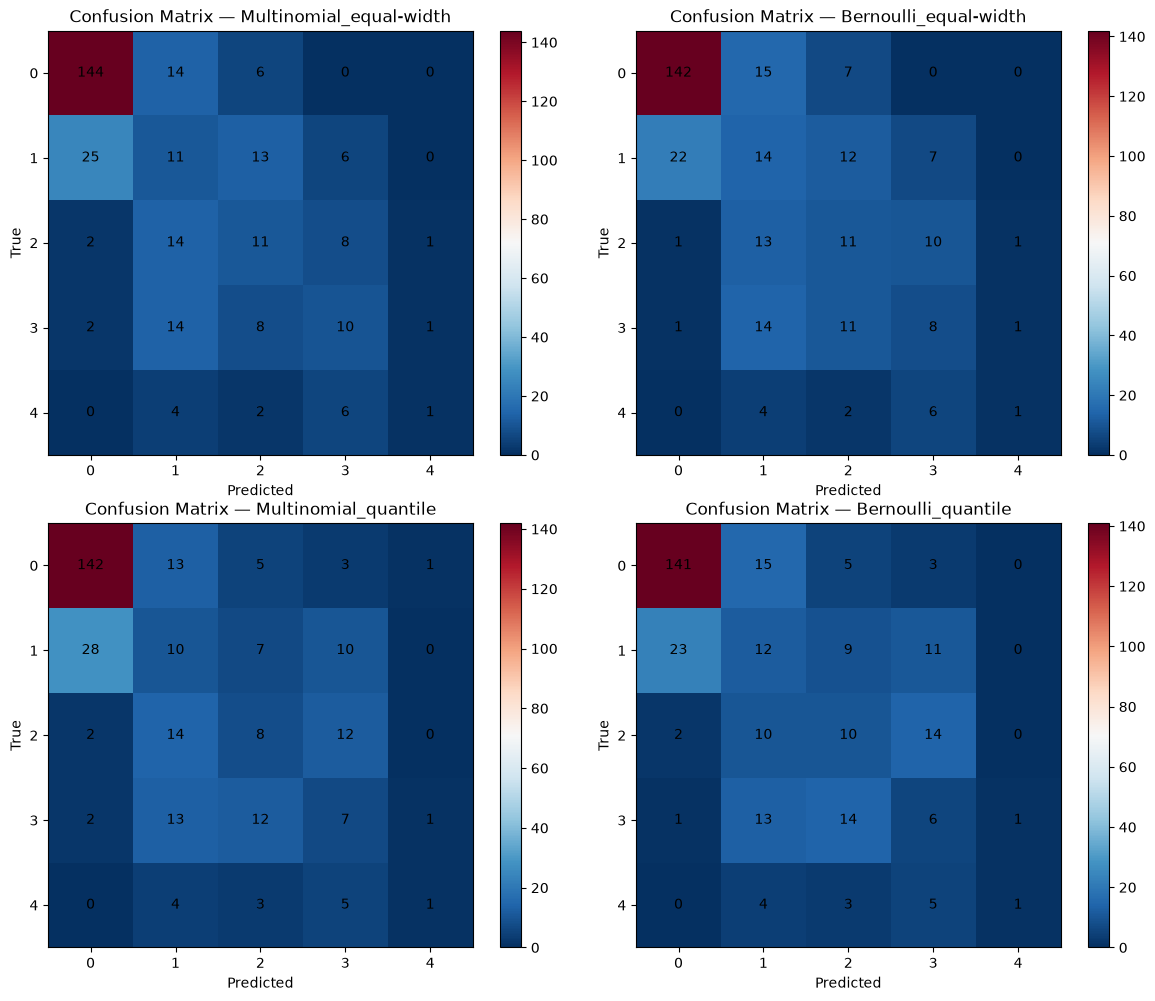

In [12]:
plot_results(experiments, "confusion")

## 8a. Per-fold confusion matrices and averaged validation results

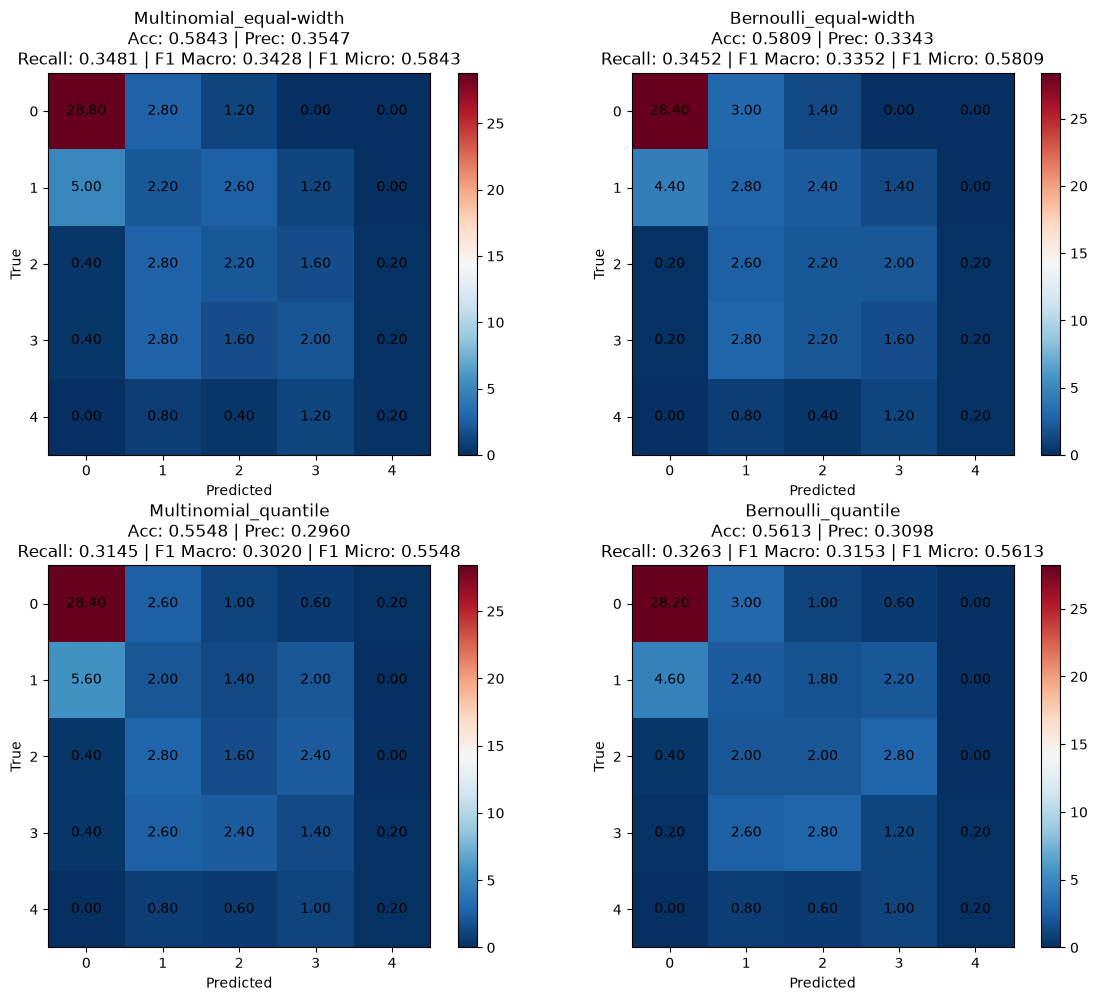

In [13]:
plot_results(experiments, "metrics")

## 9. Precision-Recall and ROC curves

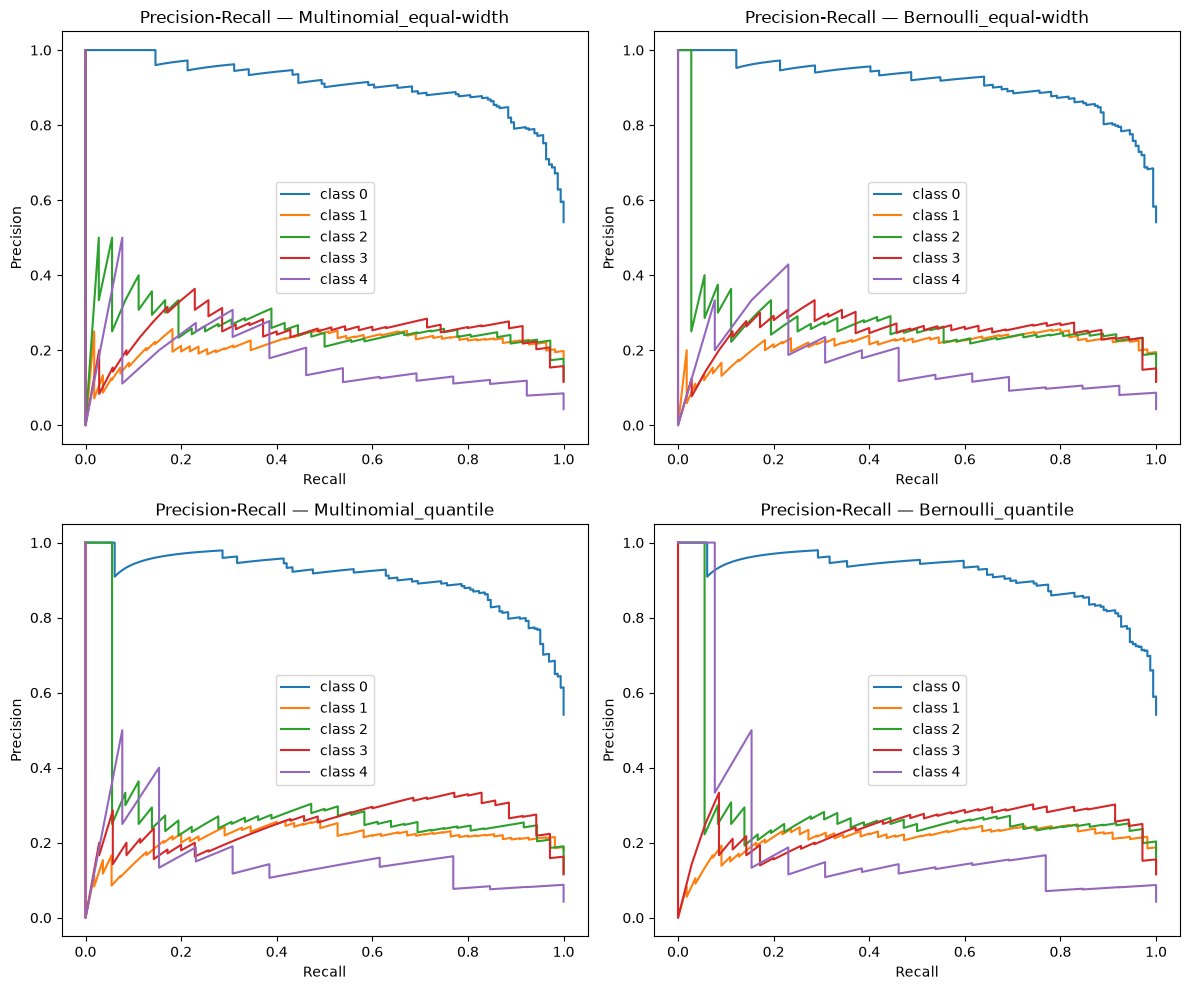

In [14]:
plot_results(experiments, "pr")

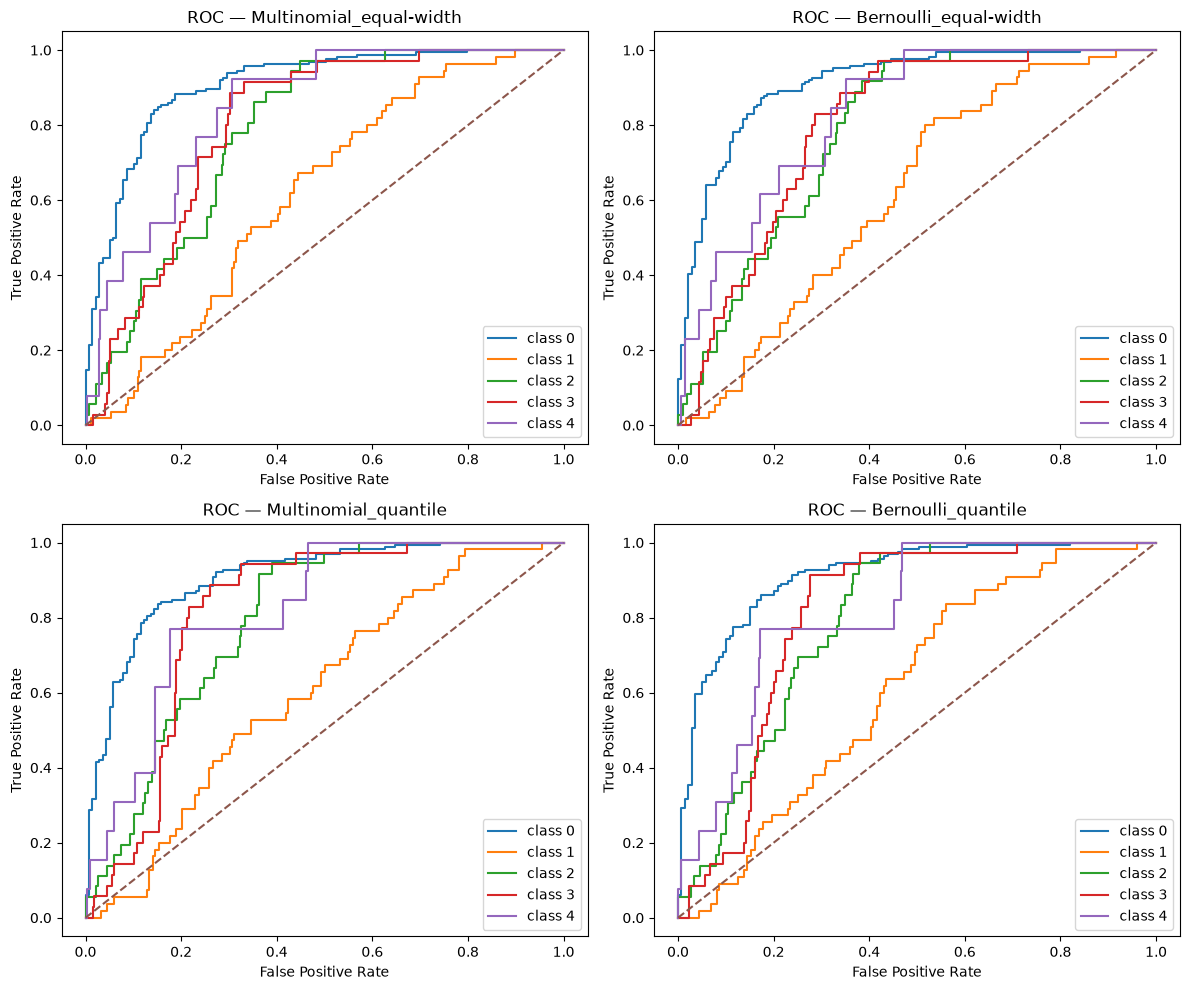

In [15]:
plot_results(experiments, "roc")

## 10. Five classes versus binary disease-present classification

In [16]:
binary_results = {}

for mode in ["equal-width", "quantile"]:
    for model_name, model_class in [("Multinomial", MultinomialNB), ("Bernoulli", BernoulliNB)]:
        key = f"{model_name}_{mode}_binary"
        
        binary_results[key] = run_cv(
            data, folds, model_class, 
            mode=mode, alpha=1.0, binary=True
        )


print("\nBinary Classification Results")
print("-" * 80)

print(
    f"{'Model':<12}"
    f"{'Binning':<15}"
    f"{'Accuracy':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
)

print("-" * 80)

for key, result in binary_results.items():
    model, mode, _ = key.split("_")

    print(
        f"{model:<12}"
        f"{mode:<15}"
        f"{result['fold_mean_accuracy']:<12.4f}"
        f"{result['fold_mean_precision_macro']:<12.4f}"
        f"{result['fold_mean_recall_macro']:<12.4f}"
        f"{result['fold_mean_f1_macro']:<12.4f}"
    )

print("-" * 80)

print("\nClass Distribution")
print("-" * 40)

print(f"{'Original 5-class':<20}: {class_counts}")

binary_counts = {
    "0": class_counts.get(0, 0),
    "1-4": sum(class_counts.get(c, 0) for c in [1, 2, 3, 4])
}

print(f"{'Binary':<20}: {binary_counts}")



Binary Classification Results
--------------------------------------------------------------------------------
Model       Binning        Accuracy    Precision   Recall      F1          
--------------------------------------------------------------------------------
Multinomial equal-width    0.8352      0.8361      0.8331      0.8335      
Bernoulli   equal-width    0.8386      0.8389      0.8379      0.8375      
Multinomial quantile       0.8321      0.8332      0.8296      0.8301      
Bernoulli   quantile       0.8256      0.8252      0.8236      0.8241      
--------------------------------------------------------------------------------

Class Distribution
----------------------------------------
Original 5-class    : {0: 164, 2: 36, 1: 55, 3: 35, 4: 13}
Binary              : {'0': 164, '1-4': 139}


## 11. Equal-width vs quantile: find a patient whose prediction changes

In [17]:
def compare_predictions(result_a, result_b):
    changed = []
    for idx in sorted(set(result_a["fold_predictions"]) & set(result_b["fold_predictions"])):
        pa = result_a["fold_predictions"][idx]
        pb = result_b["fold_predictions"][idx]
        if pa != pb:
            changed.append((idx, pa, pb))
    return changed

for model_name in ["Multinomial", "Bernoulli"]:
    a = experiments[f"{model_name}_equal-width"]
    b = experiments[f"{model_name}_quantile"]
    changed = compare_predictions(a, b)

    print(f"\n{model_name}: changed predictions = {len(changed)}")
    if changed:
        idx, pa, pb = changed[0]
        print("Example patient index:", idx)
        print("Equal-width prediction:", pa)
        print("Quantile prediction:", pb)
        print("Patient:", {k: data[idx][k] for k in COLUMNS})
    else:
        print("No changed prediction found for this model.")


Multinomial: changed predictions = 57
Example patient index: 1
Equal-width prediction: 1
Quantile prediction: 3
Patient: {'age': 67.0, 'sex': 1.0, 'cp': 4.0, 'trestbps': 160.0, 'chol': 286.0, 'fbs': 0.0, 'restecg': 2.0, 'thalach': 108.0, 'exang': 1.0, 'oldpeak': 1.5, 'slope': 2.0, 'ca': 3.0, 'thal': 3.0, 'num': 2}

Bernoulli: changed predictions = 46
Example patient index: 1
Equal-width prediction: 1
Quantile prediction: 3
Patient: {'age': 67.0, 'sex': 1.0, 'cp': 4.0, 'trestbps': 160.0, 'chol': 286.0, 'fbs': 0.0, 'restecg': 2.0, 'thalach': 108.0, 'exang': 1.0, 'oldpeak': 1.5, 'slope': 2.0, 'ca': 3.0, 'thal': 3.0, 'num': 2}


## 12. Missing-value token versus removing incomplete records

In [18]:
def make_complete_dataset(rows):
    return [row for row in rows if all(row[f] is not None for f in FEATURES)]

complete_data = make_complete_dataset(data)
complete_folds = make_stratified_folds(complete_data)

missing_results = {}

for model_name, model_class in [("Multinomial", MultinomialNB), ("Bernoulli", BernoulliNB)]:
    token_key = f"{model_name}_missing_token"
    removed_key = f"{model_name}_removed_incomplete"

    missing_results[token_key] = run_cv(
        data, folds, model_class, mode="quantile", alpha=1.0
    )
    missing_results[removed_key] = run_cv(
        complete_data, complete_folds, model_class, mode="quantile", alpha=1.0
    )

    print("\n", model_name)
    print("With explicit missing token macro F1:",
          round(missing_results[token_key]["f1_macro"], 4))
    print("After removing incomplete records macro F1:",
          round(missing_results[removed_key]["f1_macro"], 4))
    print("Complete records retained:", len(complete_data), "/", len(data))


 Multinomial
With explicit missing token macro F1: 0.3137
After removing incomplete records macro F1: 0.34
Complete records retained: 297 / 303

 Bernoulli
With explicit missing token macro F1: 0.3255
After removing incomplete records macro F1: 0.3588
Complete records retained: 297 / 303


## 13. Posterior scores for one correctly classified and one misclassified validation patient

In [19]:
# Use fold 5 as a validation example. Train on folds 1-4 and inspect its held-out records.
def inspect_validation_patients(data_rows, folds, model_class, mode="quantile"):
    test_idx = folds[-1]
    train_idx = np.concatenate(folds[:-1])

    X_train, X_test, y_train, y_test, thresholds = prepare_fold(
        data_rows, train_idx, test_idx, n_bins=10, mode=mode
    )

    model = model_class(alpha=1.0, prior_type="empirical")
    model.fit(X_train, y_train)

    log_scores = model.predict_log_proba(X_test)
    probs = model.predict_proba(X_test)
    pred = model.predict(X_test)

    correct_pos = next((i for i, (yt, yp) in enumerate(zip(y_test, pred)) if yt == yp), None)
    wrong_pos = next((i for i, (yt, yp) in enumerate(zip(y_test, pred)) if yt != yp), None)

    for label, pos in [("Correct", correct_pos), ("Misclassified", wrong_pos)]:
        if pos is None:
            print("No", label, "example found.")
            continue
        print("\n", label)
        print("Original patient index:", int(test_idx[pos]))
        print("True class:", y_test[pos])
        print("Predicted class:", pred[pos])
        print("Classes:", model.classes)
        print("Log-posterior scores:", dict(zip(model.classes, log_scores[pos])))
        print("Normalized posterior probabilities:",
              dict(zip(model.classes, probs[pos])))

inspect_validation_patients(data, folds, MultinomialNB)


 Correct
Original patient index: 7
True class: 0
Predicted class: 0
Classes: [0 1 2 3 4]
Log-posterior scores: {np.int64(0): np.float64(-49.938915921196156), np.int64(1): np.float64(-52.276313875405414), np.int64(2): np.float64(-54.8964287026439), np.int64(3): np.float64(-55.39246007888241), np.int64(4): np.float64(-58.45978191000398)}
Normalized posterior probabilities: {np.int64(0): np.float64(0.9024542788538528), np.int64(1): np.float64(0.08715778303413352), np.int64(2): np.float64(0.0063446075469841415), np.int64(3): np.float64(0.0038635013997317972), np.int64(4): np.float64(0.00017982916529783074)}

 Misclassified
Original patient index: 20
True class: 0
Predicted class: 1
Classes: [0 1 2 3 4]
Log-posterior scores: {np.int64(0): np.float64(-53.46145502508503), np.int64(1): np.float64(-51.772487355761626), np.int64(2): np.float64(-54.10405694874682), np.int64(3): np.float64(-55.54661075870967), np.int64(4): np.float64(-55.75173170890178)}
Normalized posterior probabilities: {np.in

## 14. Empirical versus uniform priors

In [21]:
prior_results = {}

for model_name, model_class in [("Multinomial", MultinomialNB), ("Bernoulli", BernoulliNB)]:
    for prior in ["empirical", "uniform"]:

        key = f"{model_name}_{prior}"

        prior_results[key] = run_cv(
            data,
            folds,
            model_class,
            mode="quantile",
            alpha=1.0,
            prior_type=prior
        )

print("\nPrior Comparison Results")
print("-" * 65)

print(
    f"{'Model':<15}"
    f"{'Prior':<15}"
    f"{'Macro-F1':<15}"
    f"{'Accuracy':<15}"
)

print("-" * 65)

for model in ["Multinomial", "Bernoulli"]:
    for prior in ["empirical", "uniform"]:
        result = prior_results[f"{model}_{prior}"]

        print(
            f"{model:<15}"
            f"{prior:<15}"
            f"{result['f1_macro']:<15.4f}"
            f"{result['accuracy']:<15.4f}"
        )

print("-" * 65)


Prior Comparison Results
-----------------------------------------------------------------
Model          Prior          Macro-F1       Accuracy       
-----------------------------------------------------------------
Multinomial    empirical      0.3137         0.5545         
Multinomial    uniform        0.3037         0.5215         
Bernoulli      empirical      0.3255         0.5611         
Bernoulli      uniform        0.3074         0.5149         
-----------------------------------------------------------------


## 15. Smoothing experiment: α = 0.5, 1, 2

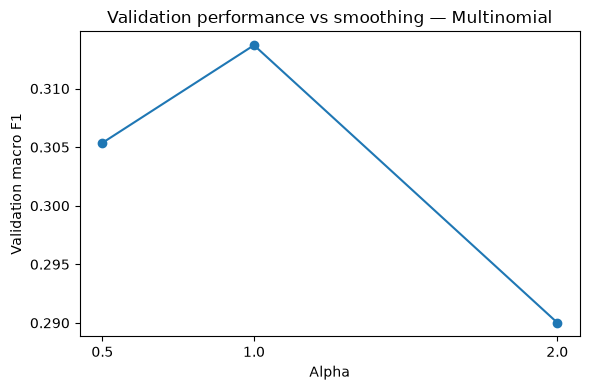

Multinomial {0.5: np.float64(0.30536582141142504), 1.0: np.float64(0.31370389640862867), 2.0: np.float64(0.2900214145829775)}


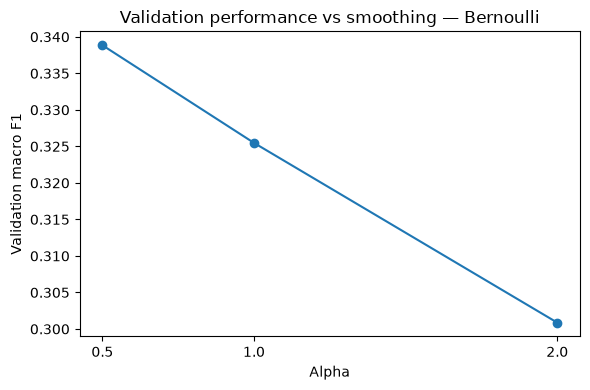

Bernoulli {0.5: np.float64(0.338852529317318), 1.0: np.float64(0.3254765975395705), 2.0: np.float64(0.30086911877956657)}


In [22]:
alphas = [0.5, 1.0, 2.0]
smoothing_results = {}

for model_name, model_class in [("Multinomial", MultinomialNB), ("Bernoulli", BernoulliNB)]:
    values = []
    for alpha in alphas:
        result = run_cv(
            data, folds, model_class,
            mode="quantile", alpha=alpha
        )
        smoothing_results[(model_name, alpha)] = result
        values.append(result["f1_macro"])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(alphas, values, marker="o")
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Validation macro F1")
    ax.set_title(f"Validation performance vs smoothing — {model_name}")
    ax.set_xticks(alphas)
    plt.tight_layout()
    plt.show()

    print(model_name, dict(zip(alphas, values)))

## 16. Normalized posteriors, multiclass log loss, and reliability diagrams

Multinomial_equal-width multiclass log loss = 1.1472042042696817
Bernoulli_equal-width multiclass log loss = 1.4388282946500406
Multinomial_quantile multiclass log loss = 1.1587022903796744
Bernoulli_quantile multiclass log loss = 1.4368155360827009


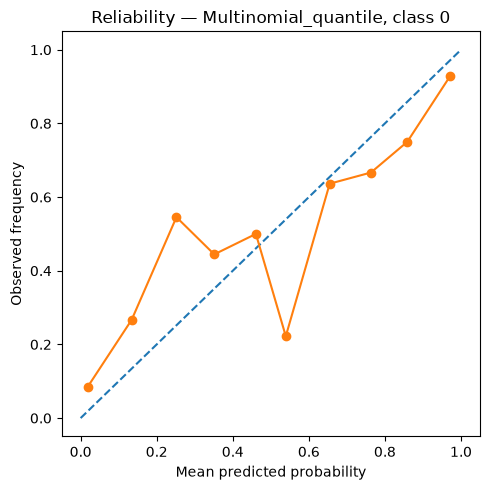

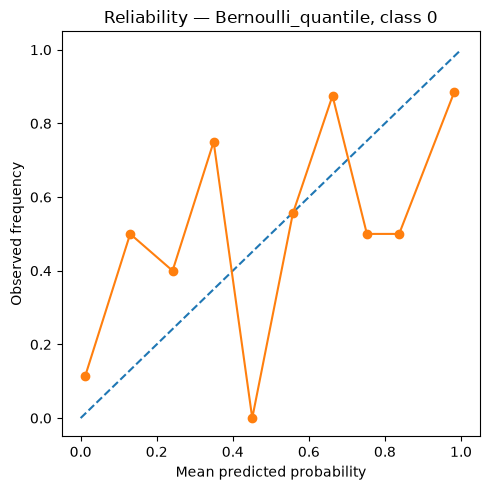

In [23]:
def multiclass_log_loss(y_true, probabilities, classes, eps=1e-15):
    class_index = {c: i for i, c in enumerate(classes)}
    losses = []
    for yt, p in zip(y_true, probabilities):
        p_true = np.clip(p[class_index[yt]], eps, 1 - eps)
        losses.append(-math.log(p_true))
    return float(np.mean(losses))

for key, result in experiments.items():
    ll = multiclass_log_loss(
        result["y_true"], result["probabilities"], result["classes"]
    )
    print(key, "multiclass log loss =", ll)

def reliability_diagram_binary(y_true, prob_positive, n_bins=10, title="Reliability diagram"):
    bins = np.linspace(0, 1, n_bins + 1)
    mean_pred, frac_positive = [], []

    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (prob_positive >= bins[i]) & (prob_positive <= bins[i+1])
        else:
            mask = (prob_positive >= bins[i]) & (prob_positive < bins[i+1])

        if np.any(mask):
            mean_pred.append(np.mean(prob_positive[mask]))
            frac_positive.append(np.mean(y_true[mask]))

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_positive, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# For a multiclass reliability view, show one-vs-rest calibration for class 0.
for key in ["Multinomial_quantile", "Bernoulli_quantile"]:
    result = experiments[key]
    class_zero_pos = np.where(result["classes"] == 0)[0][0]
    y0 = (result["y_true"] == 0).astype(int)
    p0 = result["probabilities"][:, class_zero_pos]
    reliability_diagram_binary(y0, p0, title=f"Reliability — {key}, class 0")

## 17. Sensitivity to an irrelevant shuffled feature-value token

In [24]:
def add_shuffled_token_column(rows, seed=SEED, n_values=5):
    local_rng = np.random.default_rng(seed)
    shuffled = local_rng.integers(0, n_values, size=len(rows))

    result = []
    for row, value in zip(rows, shuffled):
        new = dict(row)
        new["_shuffled_token"] = int(value)
        result.append(new)

    return result


def prepare_fold_with_shuffle(data_rows, train_idx, test_idx, n_bins=10, mode="quantile"):
    # Add the independent random token to the entire dataset first
    shuffled_data = add_shuffled_token_column(data_rows, seed=SEED)

    # Split using the original fold indices
    train_rows = [shuffled_data[i] for i in train_idx]
    test_rows = [shuffled_data[i] for i in test_idx]

    # Learn binning thresholds only from training data
    thresholds = fit_binner(train_rows, n_bins=n_bins, mode=mode)

    # Apply the same training-derived thresholds
    train_binned = apply_binner(train_rows, thresholds)
    test_binned = apply_binner(test_rows, thresholds)

    def tokens(rows):
        out = []

        for row in rows:
            current = []

            for feature in FEATURES:
                value = row[feature]
                value_text = "missing" if value is None else str(value)
                current.append(f"{feature}={value_text}")

            current.append(f"shuffled_token={row['_shuffled_token']}")
            out.append(current)

        return out

    X_train = tokens(train_binned)
    X_test = tokens(test_binned)

    y_train = np.array([r[TARGET] for r in train_rows], dtype=int)
    y_test = np.array([r[TARGET] for r in test_rows], dtype=int)

    return X_train, X_test, y_train, y_test


def run_cv_shuffled(data_rows, folds, model_class):
    all_true = []
    all_pred = []

    for fold_no in range(5):
        test_idx = folds[fold_no]
        train_idx = np.concatenate([folds[j] for j in range(5) if j != fold_no])

        Xtr, Xte, ytr, yte = prepare_fold_with_shuffle(data_rows, train_idx, test_idx)

        model = model_class(alpha=1.0)
        model.fit(Xtr, ytr)

        pred = model.predict(Xte)

        all_true.extend(yte.tolist())
        all_pred.extend(pred.tolist())

    classes = np.array(sorted(set(all_true)))

    return evaluate(np.array(all_true), np.array(all_pred), classes)


for model_name, model_class in [("Multinomial", MultinomialNB), ("Bernoulli", BernoulliNB)]:
    baseline = experiments[f"{model_name}_quantile"]
    shuffled = run_cv_shuffled(data, folds, model_class)

    print("\n", model_name)
    print("Baseline macro F1:", baseline["f1_macro"])
    print("Shuffled-token macro F1:", shuffled["f1_macro"])
    print("Change:", shuffled["f1_macro"] - baseline["f1_macro"])


 Multinomial
Baseline macro F1: 0.31370389640862867
Shuffled-token macro F1: 0.3282783882783883
Change: 0.01457449186975962

 Bernoulli
Baseline macro F1: 0.3254765975395705
Shuffled-token macro F1: 0.3397787799731841
Change: 0.014302182433613642


## 18. Compact comparison tables

In [25]:
def print_comparison_table(results_dict):
    print(f"{'Experiment':40s} {'Accuracy':>10s} {'Macro F1':>10s} {'Micro F1':>10s}")
    print("-" * 76)
    for key, result in results_dict.items():
        print(
            f"{key:40s} "
            f"{result['accuracy']:10.4f} "
            f"{result['f1_macro']:10.4f} "
            f"{result['f1_micro']:10.4f}"
        )

print("Main 5-class experiments")
print_comparison_table(experiments)

print("\nBinary experiments")
print_comparison_table(binary_results)

Main 5-class experiments
Experiment                                 Accuracy   Macro F1   Micro F1
----------------------------------------------------------------------------
Multinomial_equal-width                      0.5842     0.3546     0.5842
Bernoulli_equal-width                        0.5809     0.3500     0.5809
Multinomial_quantile                         0.5545     0.3137     0.5545
Bernoulli_quantile                           0.5611     0.3255     0.5611

Binary experiments
Experiment                                 Accuracy   Macro F1   Micro F1
----------------------------------------------------------------------------
Multinomial_equal-width_binary               0.8350     0.8335     0.8350
Bernoulli_equal-width_binary                 0.8383     0.8373     0.8383
Multinomial_quantile_binary                  0.8317     0.8300     0.8317
Bernoulli_quantile_binary                    0.8251     0.8236     0.8251


## 19. Final reproducibility check

In [26]:
print("Seed:", SEED)
print("Number of folds:", len(folds))
print("Fold sizes:", [len(f) for f in folds])
print("Notebook configuration:")
print("- Binning bins:", 10)
print("- Binning strategies: equal-width, quantile")
print("- Default alpha:", 1.0)
print("- Additional alpha values:", [0.5, 2.0])
print("- Priors: empirical, uniform")
print("- Main task: 5-class; additional task: binary 0 vs 1-4")
print("- Missing strategy: explicit token; comparison with record removal")
print("- Classifiers: manual MultinomialNB and BernoulliNB")

Seed: 42
Number of folds: 5
Fold sizes: [62, 61, 61, 60, 59]
Notebook configuration:
- Binning bins: 10
- Binning strategies: equal-width, quantile
- Default alpha: 1.0
- Additional alpha values: [0.5, 2.0]
- Priors: empirical, uniform
- Main task: 5-class; additional task: binary 0 vs 1-4
- Missing strategy: explicit token; comparison with record removal
- Classifiers: manual MultinomialNB and BernoulliNB
